In [1]:
import matplotlib.pyplot as plt
import cv2
import os
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,Dropout,MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
###########################
total_images_train_normal = os.listdir('c:/data/chest_xray/train/NORMAL/') # 정상
total_images_train_pneumonia = os.listdir('c:/data/chest_xray/train/PNEUMONIA/') #폐렴

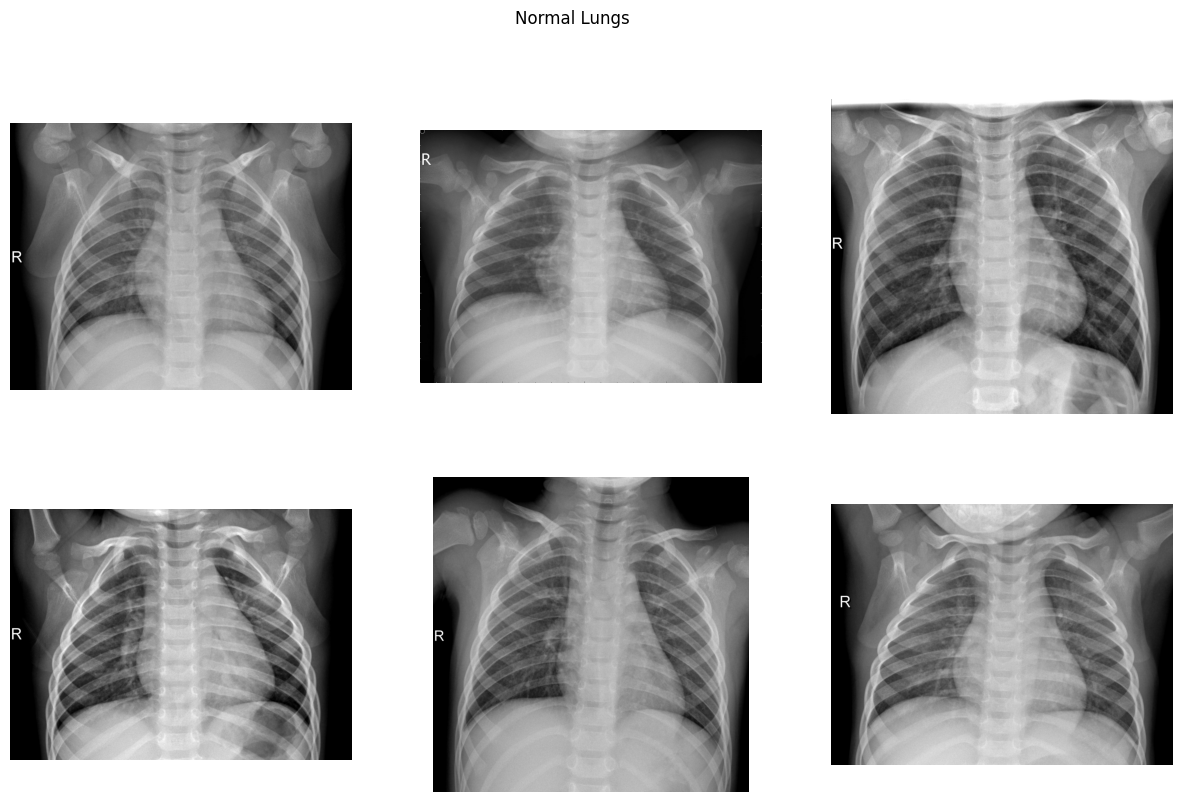

In [3]:
###########################
# 정상 폐사진
sample_normal = random.sample(total_images_train_normal,6)
f,ax = plt.subplots(2,3,figsize=(15,9))

for i in range(0,6):
    im = cv2.imread('c:/data/chest_xray/train/NORMAL/'+sample_normal[i])
    ax[i//3,i%3].imshow(im)
    ax[i//3,i%3].axis('off')

f.suptitle('Normal Lungs')
plt.show()

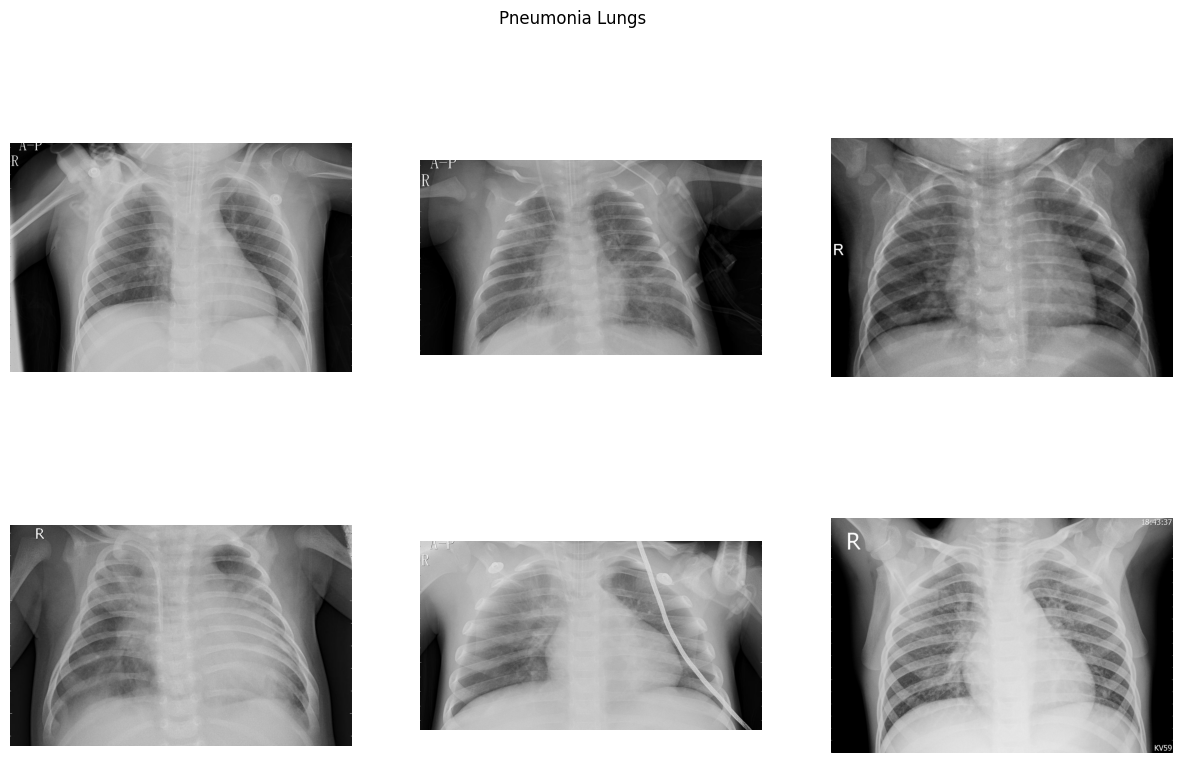

In [4]:
###########################
# 폐렴 이미지
sample_pneumonia = random.sample(total_images_train_pneumonia,6)
f,ax = plt.subplots(2,3,figsize=(15,9))

for i in range(0,6):
    im = cv2.imread('c:/data/chest_xray/train/PNEUMONIA/'+sample_pneumonia[i])
    ax[i//3,i%3].imshow(im)
    ax[i//3,i%3].axis('off')

f.suptitle('Pneumonia Lungs')
plt.show()

In [5]:
###########################
image_height = 150
image_width = 150
batch_size = 10
no_of_epochs  = 2

In [6]:
###########################
model = Sequential()
model.add(Conv2D(32,(3,3),input_shape=(image_height,image_width,3),activation='relu'))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 69, 69, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,973,665 (15.16 MB)

 Trainable params: 3,973,665 (15.16 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
###########################
train_datagen = ImageDataGenerator(rescale=1./255,     # 픽셀 값 0.0~1.0
                                   rotation_range=15,  # 15도까지 회전
                                   shear_range=0.2,    # 20%까지 기울임
                                   zoom_range=0.2      # 20%까지 확대
                                   )
val_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
###########################
training_set = train_datagen.flow_from_directory('c:/data/chest_xray/train',
                                                 target_size=(image_width, image_height),
                                                 batch_size=batch_size,
                                                 class_mode='binary')
test_set = val_datagen.flow_from_directory('c:/data/chest_xray/test',
                                            target_size=(image_width, image_height),
                                            batch_size=batch_size,
                                            class_mode='binary')
val_set = val_datagen.flow_from_directory('c:/data/chest_xray/val',
                                            target_size=(image_width, image_height),
                                            batch_size=1, #메모리 문제로 줄임, 실제학습에서는 사이즈 늘릴것
                                            shuffle=False,
                                            class_mode='binary')

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [9]:
###########################
modelCheckpoint = ModelCheckpoint('diagnose_pneumonia_model.keras', save_best_only=True)
monitor_val_acc = EarlyStopping(monitor='val_accuracy', patience=5)
history = model.fit(training_set,
                    steps_per_epoch=5216//batch_size,
                    epochs=no_of_epochs,
                    validation_data=test_set,
                    validation_steps=624//batch_size,
                    callbacks=[monitor_val_acc, modelCheckpoint]
                   )

Epoch 1/2
521/521 ━━━━━━━━━━━━━━━━━━━━ 323s 617ms/step - accuracy: 0.7428 - loss: 0.5850 - val_accuracy: 0.6258 - val_loss: 0.7319
Epoch 2/2
  1/521 ━━━━━━━━━━━━━━━━━━━━ 3:15 376ms/step - accuracy: 0.8000 - loss: 0.3901

C:\python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


521/521 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.8000 - loss: 0.3901 - val_accuracy: 0.6226 - val_loss: 0.7739


In [10]:
###########################
score = model.evaluate(test_set, steps=624//batch_size, verbose=1)
score

62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 0.6258 - loss: 0.7699


[0.7699454426765442, 0.625806450843811]

In [11]:
###########################
print(test_set.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


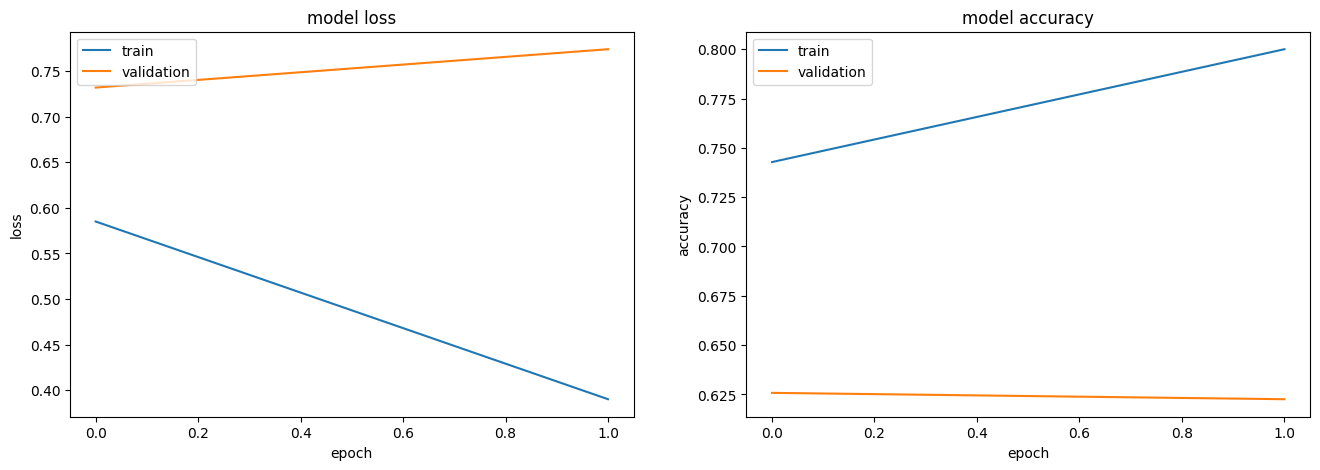

In [12]:
###########################
plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [13]:
###########################
predictions = model.predict(val_set, steps=16, verbose=1)
predictions

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


array([[0.6416662 ],
       [0.671983  ],
       [0.6428754 ],
       [0.93237776],
       [0.95489985],
       [0.68341196],
       [0.64361894],
       [0.8311882 ],
       [0.865463  ],
       [0.9063357 ],
       [0.67841744],
       [0.6498984 ],
       [0.7933029 ],
       [0.94802344],
       [0.65015626],
       [0.78379816]], dtype=float32)

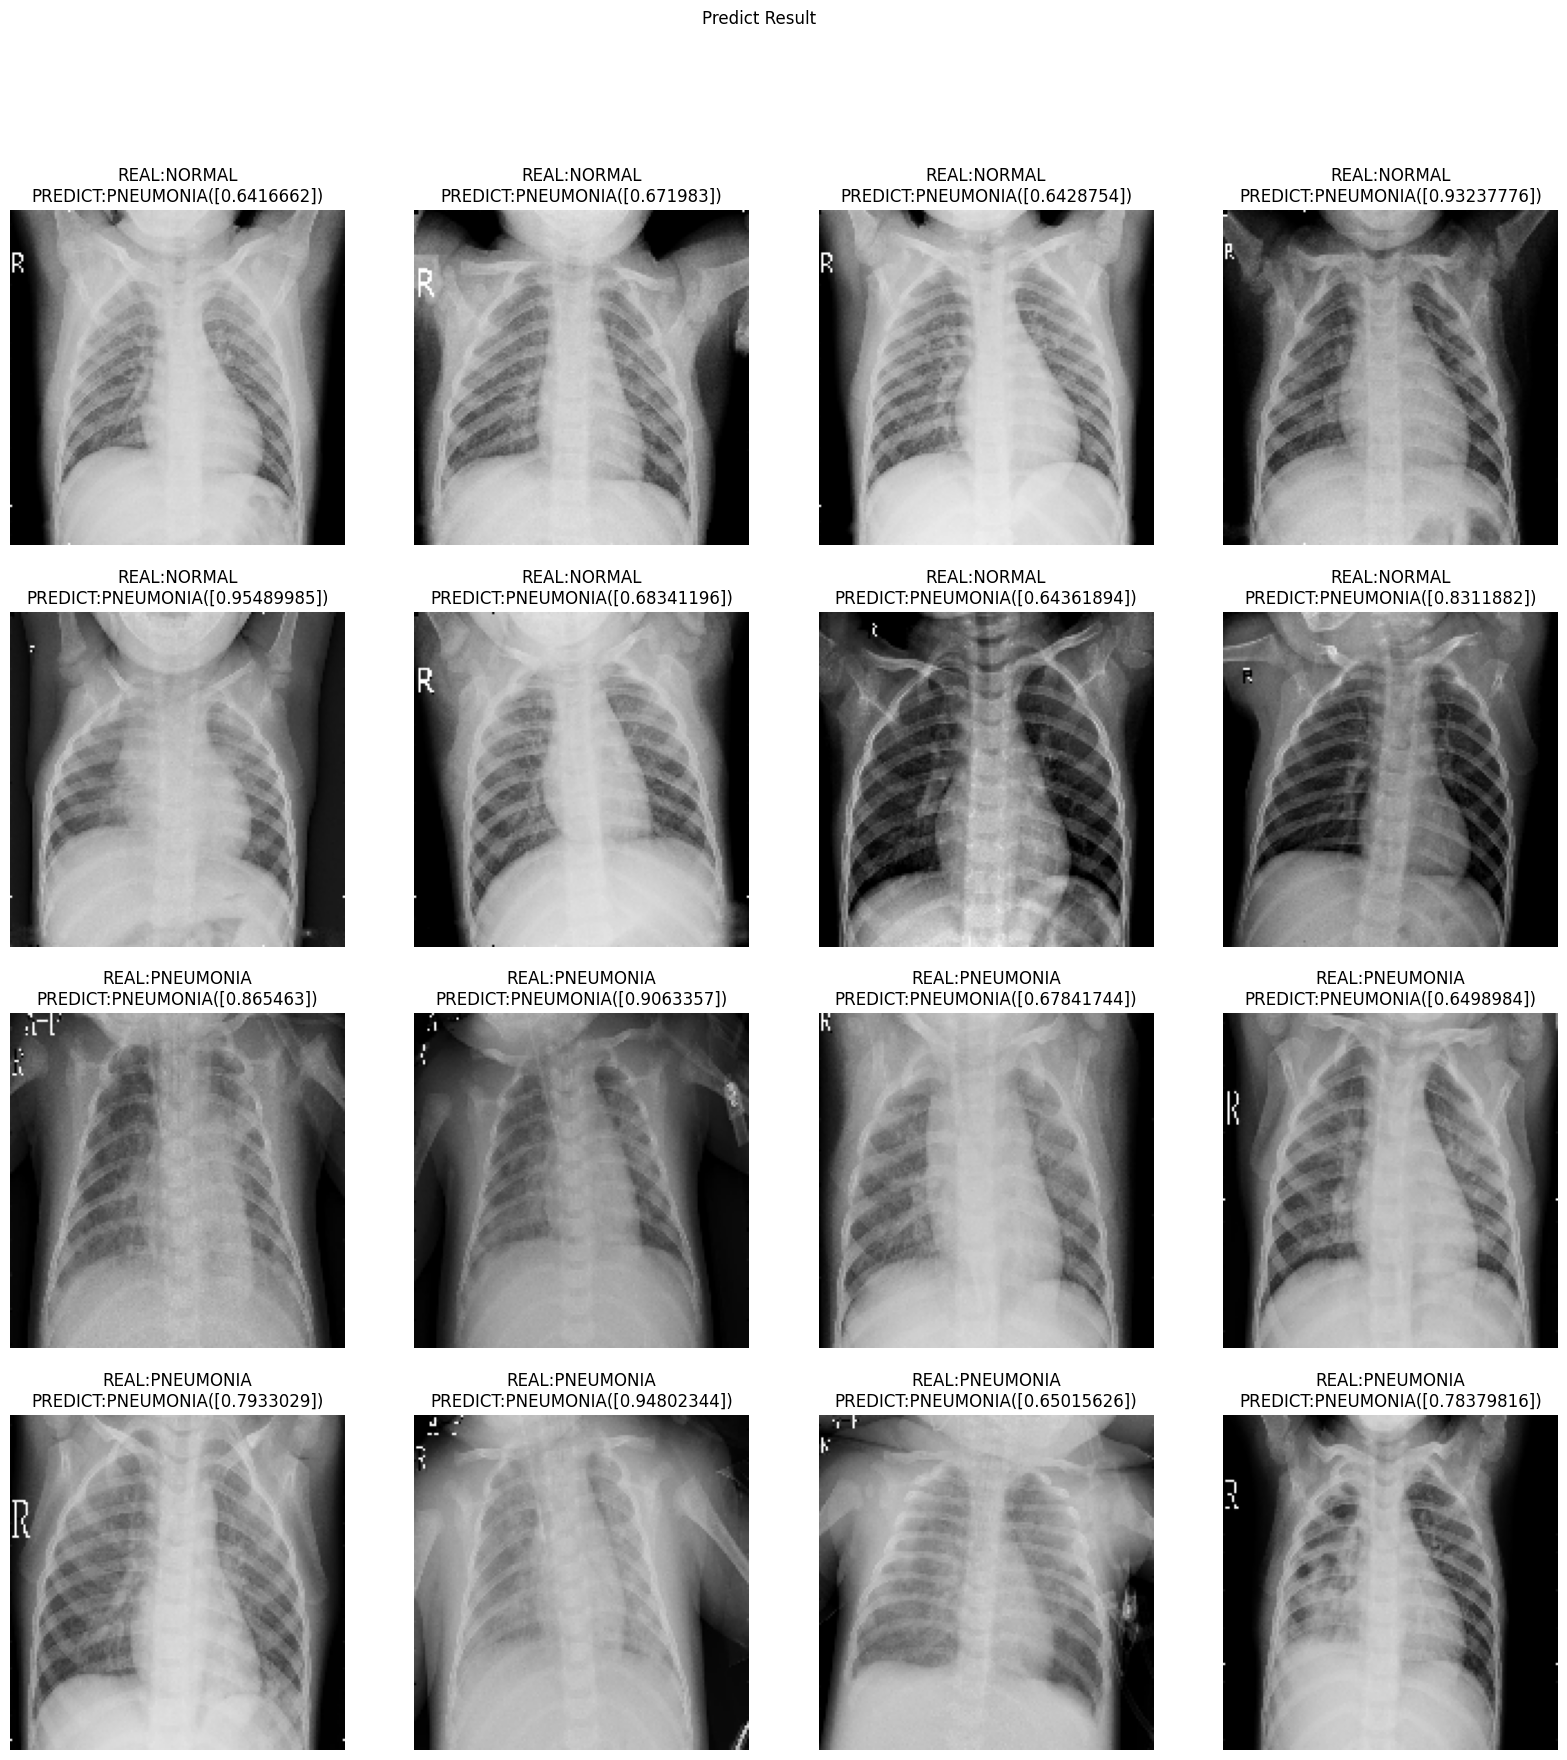

In [14]:
###########################
f, ax = plt.subplots(4, 4, figsize=(20, 20))
for i in range(len(predictions)):
    image, label = next(val_set)
    real_class = 'NORMAL' if int(label[0]) == 0 else 'PNEUMONIA'
    ax[i // 4, i % 4].imshow(image[0])
    ax[i // 4, i % 4].axis('off')
    pred_class = 'PNEUMONIA' if predictions[i] > 0.5 else 'NORMAL'
    pred_prob = predictions[i]
    ax[i // 4, i % 4].set_title('REAL:' + real_class + '\nPREDICT:' + pred_class + '(' + str(pred_prob) + ')')
f.suptitle('Predict Result')
plt.show()